# Ćwiczenie 1: Wprowadzenie do języka Python w sztucznej inteligencji

## Import bibliotek

In [6]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path(".").resolve().parent))

import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import files

## Klasa DataLoader

In [7]:
class DataLoader:
    def __init__(self):
        self.data = {}

    def load_file(self, file_type="csv"):
        """Ładowanie pliku CSV lub TXT do Pandas DataFrame"""
        uploaded = files.upload()
        for filename, content in uploaded.items():
            print(f"Ładowanie pliku: {filename}")

            if file_type == "csv":
                self.data[filename] = pd.read_csv(
                    io.BytesIO(content), sep=None, engine="python"
                )
            elif file_type == "txt":
                self.data[filename] = pd.read_csv(
                    io.BytesIO(content), sep=r"\s+", header=None, engine="python"
                )
            else:
                print("Nieobsługiwany format pliku!")
                return

            print(f"Załadowano: {filename}")

    def show_data(self):
        """Wyświetlanie załadowanych danych"""
        if not self.data:
            print("Brak załadowanych plików!")
            return

        for filename, df in self.data.items():
            print(f"\nPodgląd danych z: {filename}")
            display(df.head())

    def normalize_and_compute_distances(self):
        """Normalizacja danych i obliczenie odległości euklidesowych"""
        if not self.data:
            print("Brak załadowanych plików!")
            return

        for filename, df in self.data.items():
            print(f"\nPrzetwarzanie danych z: {filename}")
            numeric_df = df.select_dtypes(include=[np.number])
            if numeric_df.empty:
                print("Brak danych numerycznych do przetworzenia!")
                continue

            # Normalizacja względem maksymalnej wartości modułu
            max_abs_values = numeric_df.abs().max()
            normalized_df = numeric_df / max_abs_values

            # Obliczenie odległości euklidesowych
            distances = np.linalg.norm(normalized_df.values, axis=1)
            sorted_indices = np.argsort(distances)
            sorted_distances = distances[sorted_indices]

            print("Posortowane odległości od początku układu współrzędnych:")
            print(sorted_distances)

            # Rysowanie wykresu logarytmicznego odległości
            plt.figure()
            plt.semilogy(sorted_distances)
            plt.title(f"Odległości euklidesowe (log) — {filename}")
            plt.xlabel("Indeks")
            plt.ylabel("Odległość (skala log)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()

            # Zapisanie znormalizowanych danych do pliku xlsx
            output_name = filename.rsplit(".", 1)[0] + "_normalized.xlsx"
            normalized_df.to_excel(output_name, index=False)
            print(f"Zapisano znormalizowane dane do: {output_name}")

## Ładowanie danych

In [8]:
loader = DataLoader()
print("Wgraj plik CSV lub TXT:")
loader.load_file(file_type="csv")  # Zmień na 'txt' dla plików tekstowych

Wgraj plik CSV lub TXT:
Załadowano 'CSV.csv' (59316 bajtów)
Ładowanie pliku: CSV.csv
Załadowano: CSV.csv


## Podgląd danych

In [9]:
loader.show_data()


Podgląd danych z: CSV.csv


,﻿Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,...,Column47,Column48,Column49,Column50,Column51,Column52,Column53,Column54,Column55,Category
0,1,0.000067,0.000036,0.975478,0.000129,0.000098,-0.975478,0.000192,0.000161,0.975478,...,0.000157,0.000016,-0.000137,0.000192,0.000104,0.229309,0.000267,0.000174,-0.036228,-13.0
1,2,0.000070,0.000038,0.935795,0.000132,0.000101,-0.935795,0.000195,0.000163,0.935795,...,0.000156,0.000024,-0.001025,0.000197,0.000106,0.227331,0.000269,0.000176,-0.052882,-12.0
2,3,0.000072,0.000041,0.891492,0.000134,0.000103,-0.891492,0.000197,0.000166,0.891492,...,0.000152,0.000029,-0.003201,0.000199,0.000106,0.232464,0.000268,0.000175,-0.076481,-11.0
3,4,0.000075,0.000044,0.806227,0.000138,0.000106,-0.806224,0.000200,0.000169,0.806224,...,0.000159,0.000037,-0.006754,0.000202,0.000112,0.176832,0.000274,0.000180,-0.046797,0.0
4,5,0.000078,0.000047,0.717216,0.000140,0.000109,-0.717210,0.000203,0.000172,0.717210,...,0.000164,0.000042,-0.010491,0.000205,0.000116,0.140949,0.000277,0.000184,-0.034256,11.0


## Normalizacja danych i obliczenie odległości euklidesowych


Przetwarzanie danych z: CSV.csv
Posortowane odległości od początku układu współrzędnych:
[5.35429674 5.46882584 5.49555393 5.56511725 5.58975197 5.59426963
 5.63702885 5.64111238 5.64892131 5.6618363  5.67749017 5.69993838
 5.70919563 5.70986735 5.73472488 5.73544056 5.74158647 5.74741371
 5.76358728 5.7723666  5.77811369 5.78097333 5.78280735 5.79175803
 5.79337679 5.79545231 5.7960774  5.81052408 5.8121674  5.81395579
 5.81457084 5.81509113 5.81559733 5.81701251 5.82470069 5.8384481
 5.84090746 5.8427994  5.84429308 5.85004441 5.85565206 5.8605373
 5.86095076 5.87097356 5.87296136 5.88528364 5.88925112 5.89176156
 5.89734864 5.90000333 5.9027757  5.90385281 5.90949476 5.92723193
 5.93063194 5.93478089 5.9349157  5.96369826 5.97149997 5.97350145
 5.97901196 5.99180802 6.01605824 6.08945511 6.09539794 6.1088699
 6.15383315 6.16979036 6.22966307 6.40626915]


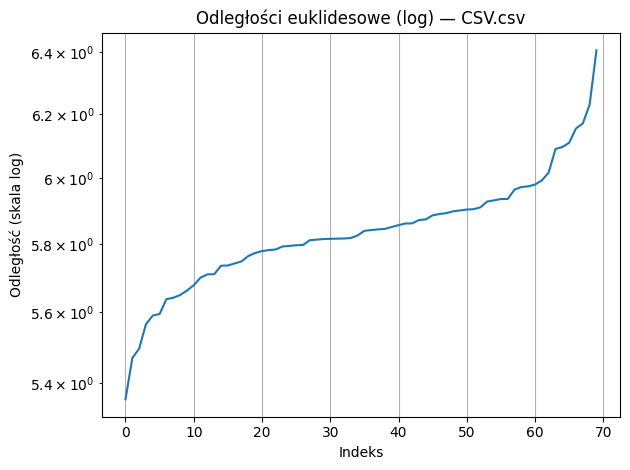

Zapisano znormalizowane dane do: CSV_normalized.xlsx


In [10]:
loader.normalize_and_compute_distances()